# The Business Context

**Client Company**

The following explanatory data analysis pipeline was made for the Department of Health & Human Services (HHS) of the United States of America which is responsible for improving the well-being of the citizens. One of the major challenges for this department is to reduce the prevalence and cost burden of chronic diseases, most especially heart disease and diabetes which are two of the most expensive to treat and deadly diseases in the US.


**Data Type**

This project uses a reduced version of the CDC which is a major part of the Behavioral Risk Factor Surveillance System (BRFSS)[1]. The dataset contains categorical and numerical data types regarding health status of more than 445,000 US citizen. These data include health factors such as different diseases and difficulties, lifestyle factors such as sleep duration and physical activity, and general factors such as age and sex.


**Why They Need A Data Scientist**

Heart disease and diabete are the 1st and 4th most expensive diseases to treat. In the United States, heart diseas is the leading cause of death amongst other diseases. With respect to the mentioned statistics HHS needs data-driven insights to identify population with high risk of experiencing these diseases, understand the correlation between lifestyle factors and the diseases, improve prevention plans, and target awareness campaigns more effectively.


In [1]:
# Connect colab to personal drive file storage
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import neccessary libraries
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
from matplotlib.patches import Patch

In [3]:
# This class was adopted from [2] in References section

class BubbleChart:
    def __init__(self, area, bubble_spacing=0):
        """
        Setup for bubble collapse.

        Parameters
        ----------
        area : array-like
            Area of the bubbles.
        bubble_spacing : float, default: 0
            Minimal spacing between bubbles after collapsing.

        Notes
        -----
        If "area" is sorted, the results might look weird.
        """
        area = np.asarray(area)
        r = np.sqrt(area / np.pi)

        self.bubble_spacing = bubble_spacing
        self.bubbles = np.ones((len(area), 4))
        self.bubbles[:, 2] = r
        self.bubbles[:, 3] = area
        self.maxstep = 2 * self.bubbles[:, 2].max() + self.bubble_spacing
        self.step_dist = self.maxstep / 2

        # calculate initial grid layout for bubbles
        length = np.ceil(np.sqrt(len(self.bubbles)))
        grid = np.arange(length) * self.maxstep
        gx, gy = np.meshgrid(grid, grid)
        self.bubbles[:, 0] = gx.flatten()[:len(self.bubbles)]
        self.bubbles[:, 1] = gy.flatten()[:len(self.bubbles)]

        self.com = self.center_of_mass()

    def center_of_mass(self):
        return np.average(
            self.bubbles[:, :2], axis=0, weights=self.bubbles[:, 3]
        )

    def center_distance(self, bubble, bubbles):
        return np.hypot(bubble[0] - bubbles[:, 0],
                        bubble[1] - bubbles[:, 1])

    def outline_distance(self, bubble, bubbles):
        center_distance = self.center_distance(bubble, bubbles)
        return center_distance - bubble[2] - \
            bubbles[:, 2] - self.bubble_spacing

    def check_collisions(self, bubble, bubbles):
        distance = self.outline_distance(bubble, bubbles)
        return len(distance[distance < 0])

    def collides_with(self, bubble, bubbles):
        distance = self.outline_distance(bubble, bubbles)
        return np.argmin(distance, keepdims=True)

    def collapse(self, n_iterations=50):
        """
        Move bubbles to the center of mass.

        Parameters
        ----------
        n_iterations : int, default: 50
            Number of moves to perform.
        """
        for _i in range(n_iterations):
            moves = 0
            for i in range(len(self.bubbles)):
                rest_bub = np.delete(self.bubbles, i, 0)
                # try to move directly towards the center of mass
                # direction vector from bubble to the center of mass
                dir_vec = self.com - self.bubbles[i, :2]

                # shorten direction vector to have length of 1
                dir_vec = dir_vec / np.sqrt(dir_vec.dot(dir_vec))

                # calculate new bubble position
                new_point = self.bubbles[i, :2] + dir_vec * self.step_dist
                new_bubble = np.append(new_point, self.bubbles[i, 2:4])

                # check whether new bubble collides with other bubbles
                if not self.check_collisions(new_bubble, rest_bub):
                    self.bubbles[i, :] = new_bubble
                    self.com = self.center_of_mass()
                    moves += 1
                else:
                    # try to move around a bubble that you collide with
                    # find colliding bubble
                    for colliding in self.collides_with(new_bubble, rest_bub):
                        # calculate direction vector
                        dir_vec = rest_bub[colliding, :2] - self.bubbles[i, :2]
                        dir_vec = dir_vec / np.sqrt(dir_vec.dot(dir_vec))
                        # calculate orthogonal vector
                        orth = np.array([dir_vec[1], -dir_vec[0]])
                        # test which direction to go
                        new_point1 = (self.bubbles[i, :2] + orth *
                                      self.step_dist)
                        new_point2 = (self.bubbles[i, :2] - orth *
                                      self.step_dist)
                        dist1 = self.center_distance(
                            self.com, np.array([new_point1]))
                        dist2 = self.center_distance(
                            self.com, np.array([new_point2]))
                        new_point = new_point1 if dist1 < dist2 else new_point2
                        new_bubble = np.append(new_point, self.bubbles[i, 2:4])
                        if not self.check_collisions(new_bubble, rest_bub):
                            self.bubbles[i, :] = new_bubble
                            self.com = self.center_of_mass()

            if moves / len(self.bubbles) < 0.1:
                self.step_dist = self.step_dist / 2

    def plot(self, ax, labels, colors):
        """
        Draw the bubble plot.

        Parameters
        ----------
        ax : matplotlib.axes.Axes
        labels : list
            Labels of the bubbles.
        colors : list
            Colors of the bubbles.
        """
        for i in range(len(self.bubbles)):
            circ = plt.Circle(
                self.bubbles[i, :2], self.bubbles[i, 2], color=colors[i])
            ax.add_patch(circ)
            ax.text(*self.bubbles[i, :2], labels[i],
                    horizontalalignment='center', verticalalignment='center')

In [4]:
# Assign the dataset to a DataFrame using panda
heart_dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/heart_2022_with_nans.csv')

# Data Exploration Discussion


**Dataset Characteristics**

The dataset include both numerical and categorical values ranging from lifestyle factors such as sleep duration and physical activity to health factors such as various difficulties and illnesses, as well as general factors such as sex and age. It has 445,000 rows and 40 columns, and shows several missing values across all the columns.


**Data Quality Issue**

The original dataset contains missing values across different features. Moreover, the dataset might also suffer from possible bias as it is based on participants responses in a survay, and not clinical examinations.


**Interesting Metadata** [3]

* The statistics of the data shows almost 75% of the participants are either overweighted or obese.
* The number of male and female participants are fairly the same (52% female and 47% male).
* On average people claim to be in a good mental and physical condition 25 days out of the past 30 days.
* Most columns have a categorical Y/N value.
* Since most of the columns are categorical, a better illustration for association between columns can be seen on a correlation matrix. The darker shades of blue indicate positive correlation between the two columns while the bright shades suggest negative correlation. This matrix was studied carefully, and the association between columns were further explored to present 5 informative insights.

# Data Preprocessing

The dataset is fairly clean, however it has some null values across the columns. Since the size of original dataset is quite large, for computational expense purposes, all the rows with null values were removed to shrink down the size. However, despite dropping the null values, the size of the dataset is still massive. Therefore 3000 random rows were selected from the original dataset to create a new sample set that can be computed and processed in a reasonable time.

Moreover, a custom mapping process was adopted to encode numerical values to categorical classes in each column with Object datatype. This was done so that the plotting of correlation matrix is possible and meaningful. The State column was excluded from the matrix due to non-ordinal nature.

In [5]:
# Shows the type of each column

#heart_dataset.dtypes

In [6]:
# Shows the number of rows and columns

heart_dataset.shape

(445132, 40)

In [7]:
# A glance at the dataset

heart_dataset.head()

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,No,...,NaN,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
1,Alabama,Female,Excellent,0.0,0.0,NaN,No,6.0,NaN,No,...,1.60,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
2,Alabama,Female,Very good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,No,...,1.57,63.50,25.61,No,No,No,No,NaN,No,Yes
3,Alabama,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,...,1.65,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
4,Alabama,Female,Fair,2.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,No,...,1.57,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No


In [8]:
# Prints the number of null values in the dataset

nan_count = heart_dataset.select_dtypes(include=['object', 'int64', 'float64']).isnull().sum()
print(nan_count)

State                            0
Sex                              0
GeneralHealth                 1198
PhysicalHealthDays           10927
MentalHealthDays              9067
LastCheckupTime               8308
PhysicalActivities            1093
SleepHours                    5453
RemovedTeeth                 11360
HadHeartAttack                3065
HadAngina                     4405
HadStroke                     1557
HadAsthma                     1773
HadSkinCancer                 3143
HadCOPD                       2219
HadDepressiveDisorder         2812
HadKidneyDisease              1926
HadArthritis                  2633
HadDiabetes                   1087
DeafOrHardOfHearing          20647
BlindOrVisionDifficulty      21564
DifficultyConcentrating      24240
DifficultyWalking            24012
DifficultyDressingBathing    23915
DifficultyErrands            25656
SmokerStatus                 35462
ECigaretteUsage              35660
ChestScan                    56046
RaceEthnicityCategor

In [9]:
# Drops all the null values in the dataset and store the remaing as a new dataset

heart_nonull = heart_dataset.dropna()
print(heart_nonull.shape)

(246022, 40)


In [10]:
# Selects 3000 random rows

heart_sample = heart_nonull.sample(n=3000, random_state=42)
print(heart_sample.shape)

(3000, 40)


In [11]:
# Checks if any null value left

nan_count = heart_sample.select_dtypes(include=['object', 'int64', 'float64']).isnull().sum()
print(nan_count)

State                        0
Sex                          0
GeneralHealth                0
PhysicalHealthDays           0
MentalHealthDays             0
LastCheckupTime              0
PhysicalActivities           0
SleepHours                   0
RemovedTeeth                 0
HadHeartAttack               0
HadAngina                    0
HadStroke                    0
HadAsthma                    0
HadSkinCancer                0
HadCOPD                      0
HadDepressiveDisorder        0
HadKidneyDisease             0
HadArthritis                 0
HadDiabetes                  0
DeafOrHardOfHearing          0
BlindOrVisionDifficulty      0
DifficultyConcentrating      0
DifficultyWalking            0
DifficultyDressingBathing    0
DifficultyErrands            0
SmokerStatus                 0
ECigaretteUsage              0
ChestScan                    0
RaceEthnicityCategory        0
AgeCategory                  0
HeightInMeters               0
WeightInKilograms            0
BMI     

In [12]:
# Displays the statistics of the numerical columns

heart_sample.describe()

,PhysicalHealthDays,MentalHealthDays,SleepHours,HeightInMeters,WeightInKilograms,BMI
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,4.124667,4.388000,7.010000,1.700827,83.595063,28.803797
std,8.416337,8.340342,1.380049,0.107255,21.481906,6.572398
min,0.000000,0.000000,1.000000,0.970000,38.560000,15.060000
25%,0.000000,0.000000,6.000000,1.630000,68.040000,24.295000
50%,0.000000,0.000000,7.000000,1.700000,81.650000,27.650000
75%,3.000000,5.000000,8.000000,1.780000,95.250000,32.112500
max,30.000000,30.000000,22.000000,2.260000,249.480000,78.880000


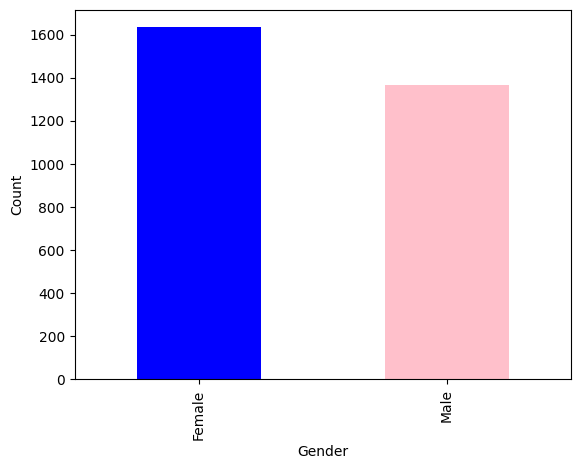

Sex
Female    1633
Male      1367
Name: count, dtype: int64
Sex
Female    0.529939
Male      0.470061
Name: proportion, dtype: float64


In [13]:
# Checks the class balance in Sex column

count=heart_sample['Sex'].value_counts()
count.plot(kind='bar', color=['blue', 'pink'])
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()
print(count)
print(heart_dataset['Sex'].value_counts(normalize=True))

In [14]:
# Prints the classes/ unique values each column has
cat_cols = heart_sample.select_dtypes(include=['object', 'category']).columns.tolist()

for col in cat_cols:
    print(f"\n{col}:")
    print(heart_sample[col].value_counts(dropna=False))
    print("Unique values:", heart_sample[col].unique())


State:
State
Washington              181
Maryland                121
New York                121
Ohio                    119
Florida                 114
Minnesota                98
Texas                    76
Massachusetts            72
Indiana                  71
Wisconsin                70
Kansas                   70
Hawaii                   70
Iowa                     69
Vermont                  67
Virginia                 66
Nebraska                 65
California               65
Utah                     65
Michigan                 64
Connecticut              64
Maine                    63
Arizona                  62
Colorado                 60
Georgia                  59
Missouri                 56
South Carolina           55
South Dakota             52
Montana                  50
Tennessee                47
Puerto Rico              46
Idaho                    42
New Jersey               40
Oregon                   39
West Virginia            38
New Hampshire            38
Arkans

In [15]:
# Creates an encoding for all the unique values in the categorical columns

heart_df = pd.DataFrame()

custom_mapping = {
    "Sex": {
        "Male": 0,
        "Female": 1
    },

    "GeneralHealth": {
        "Excellent": 0,
        "Very good": 1,
        "Good": 2,
        "Fair": 3,
        "Poor": 4
    },

    "LastCheckupTime": {
        "Within past year (anytime less than 12 months ago)": 0,
        "Within past 2 years (1 year but less than 2 years ago)": 1,
        "Within past 5 years (2 years but less than 5 years ago)": 2,
        "5 or more years ago": 3
    },

    "PhysicalActivities": {
        "No": 0,
        "Yes": 1
    },

    "RemovedTeeth": {
        "None of them": 0,
        "1 to 5": 1,
        "6 or more, but not all": 2,
        "All": 3
    },

    "HadHeartAttack": {"No": 0, "Yes": 1},
    "HadAngina": {"No": 0, "Yes": 1},
    "HadStroke": {"No": 0, "Yes": 1},
    "HadAsthma": {"No": 0, "Yes": 1},
    "HadSkinCancer": {"No": 0, "Yes": 1},
    "HadCOPD": {"No": 0, "Yes": 1},
    "HadDepressiveDisorder": {"No": 0, "Yes": 1},
    "HadKidneyDisease": {"No": 0, "Yes": 1},
    "HadArthritis": {"No": 0, "Yes": 1},

    "HadDiabetes": {
        "No": 0,
        "No, pre-diabetes or borderline diabetes": 1,
        "Yes, but only during pregnancy (female)": 2,
        "Yes": 3
    },

    "DeafOrHardOfHearing": {"No": 0, "Yes": 1},
    "BlindOrVisionDifficulty": {"No": 0, "Yes": 1},
    "DifficultyConcentrating": {"No": 0, "Yes": 1},
    "DifficultyWalking": {"No": 0, "Yes": 1},
    "DifficultyDressingBathing": {"No": 0, "Yes": 1},
    "DifficultyErrands": {"No": 0, "Yes": 1},

    "SmokerStatus": {
        "Never smoked": 0,
        "Former smoker": 1,
        "Current smoker - now smokes some days": 2,
        "Current smoker - now smokes every day": 3
    },

    "ECigaretteUsage": {
        "Never used e-cigarettes in my entire life": 0,
        "Not at all (right now)": 1,
        "Use them some days": 2,
        "Use them every day": 3
    },

    "ChestScan": {"No": 0, "Yes": 1},

    "RaceEthnicityCategory": {
        "White only, Non-Hispanic": 0,
        "Black only, Non-Hispanic": 1,
        "Hispanic": 2,
        "Other race only, Non-Hispanic": 3,
        "Multiracial, Non-Hispanic": 4
    },

    "AgeCategory": {
        "Age 18 to 24": 0,
        "Age 25 to 29": 1,
        "Age 30 to 34": 2,
        "Age 35 to 39": 3,
        "Age 40 to 44": 4,
        "Age 45 to 49": 5,
        "Age 50 to 54": 6,
        "Age 55 to 59": 7,
        "Age 60 to 64": 8,
        "Age 65 to 69": 9,
        "Age 70 to 74": 10,
        "Age 75 to 79": 11,
        "Age 80 or older": 12
    },

    "AlcoholDrinkers": {"No": 0, "Yes": 1},
    "HIVTesting": {"No": 0, "Yes": 1},
    "FluVaxLast12": {"No": 0, "Yes": 1},
    "PneumoVaxEver": {"No": 0, "Yes": 1},

    "TetanusLast10Tdap": {
        "No, did not receive any tetanus shot in the past 10 years": 0,
        "Yes, received tetanus shot but not sure what type": 1,
        "Yes, received tetanus shot, but not Tdap": 2,
        "Yes, received Tdap": 3
    },

    "HighRiskLastYear": {"No": 0, "Yes": 1},

    "CovidPos": {
        "No": 0,
        "Tested positive using home test without a health professional": 1,
        "Yes": 2
    }
}


# Iterate through each column in the DataFrame
for column in heart_sample.columns:
    if column in ['State']:
        continue
    # Check if the column is categorical (object type)
    if str(heart_sample[column].dtype).startswith(('object', 'string', 'category')):
        # Use custom mapping if available
        if column in custom_mapping:
            heart_df[column] = heart_sample[column].map(custom_mapping[column])
        else:
            continue
    # Assigning non categorical columns as they are to the 'heart' dataframe
    else:
      heart_df[column] = heart_sample[column]

<Axes: >

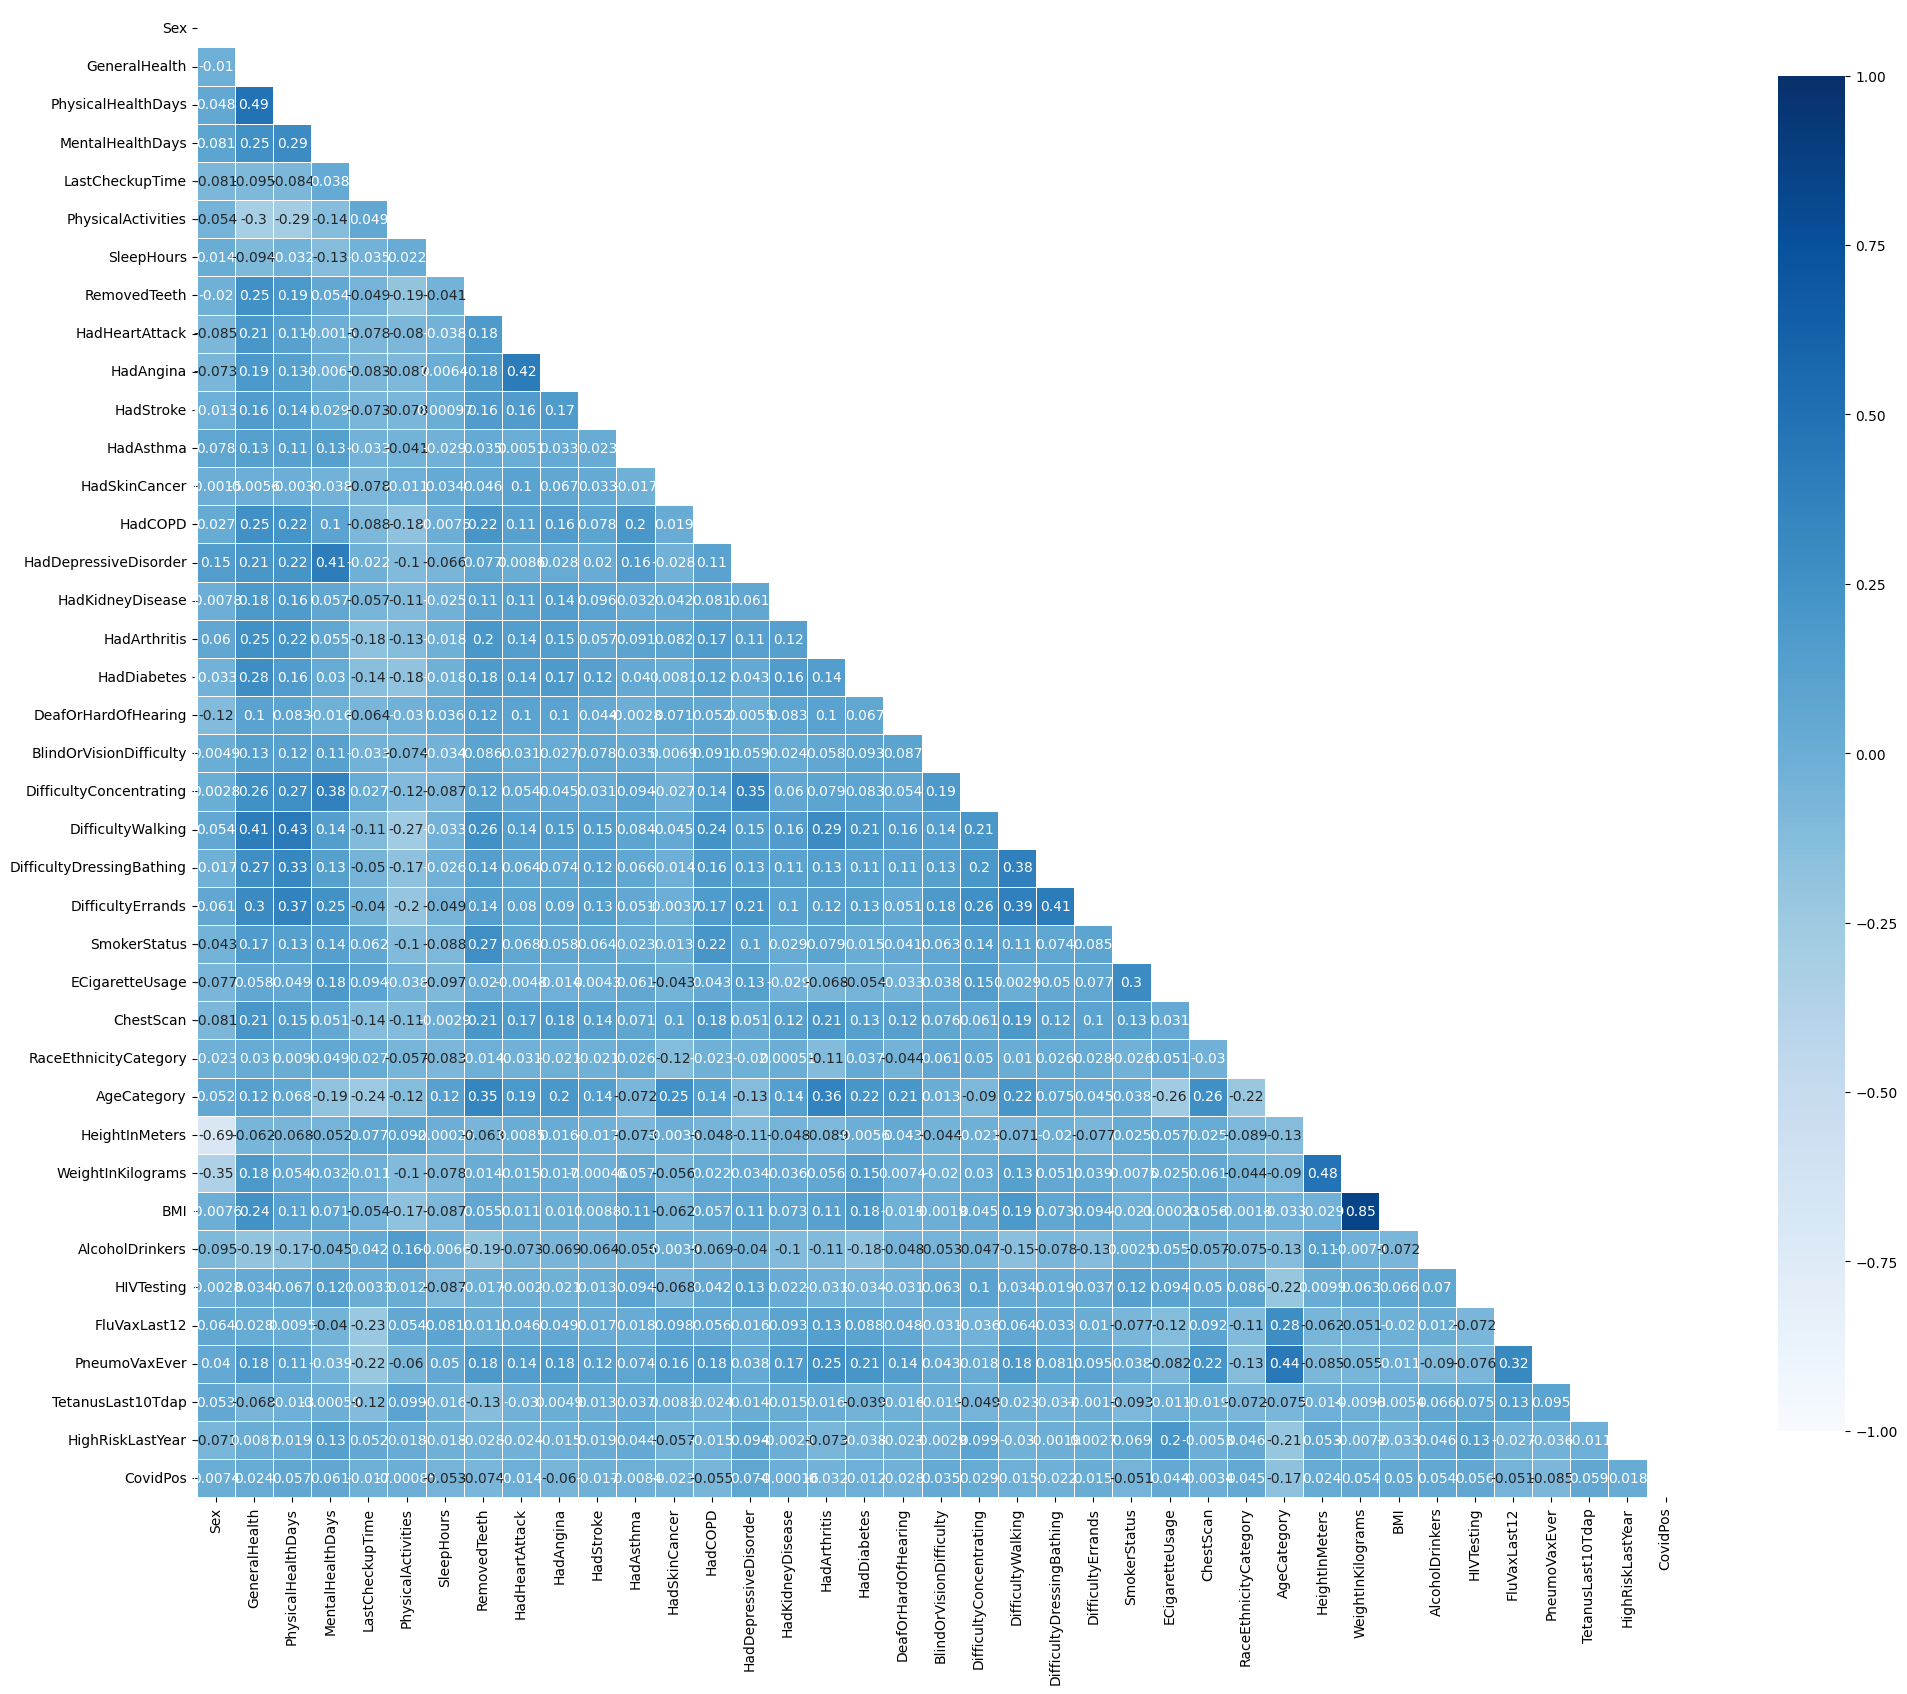

In [16]:
# Plots a corrolation matrix

plt.figure(figsize=(24, 22))

corr_matrix= heart_df.corr()

mask = np.zeros_like(corr_matrix)
mask[np.triu_indices_from(mask)] = True


sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='Blues', vmin=-1, vmax=1,
            center=0, linewidths=0.6, linecolor='white', cbar_kws={"shrink": 0.8}, square=True)

# Explanatory Data Analysis

In [17]:
# Design setting for Plotly

pio.templates["plotly_white"].layout.update(
    title=dict(
        font=dict(color="#005182", size=25),
    subtitle=dict(
        font=dict(color="#3c3c3c", size=14),
        ),
    ),

    xaxis=dict(
        title_font_color = "#777777",
        tickfont_color   = "#777777"
    ),
    yaxis=dict(
        title_font_color = "#777777",
        tickfont_color   = "#777777"
    ),
    xaxis_showgrid=False,
    yaxis_showgrid=False,
    width=1300,
    height=500
)

Layout({
    'annotationdefaults': {'arrowcolor': '#2a3f5f', 'arrowhead': 0, 'arrowwidth': 1},
    'autotypenumbers': 'strict',
    'coloraxis': {'colorbar': {'outlinewidth': 0, 'ticks': ''}},
    'colorscale': {'diverging': [[0, '#8e0152'], [0.1, '#c51b7d'], [0.2,
                                 '#de77ae'], [0.3, '#f1b6da'], [0.4, '#fde0ef'],
                                 [0.5, '#f7f7f7'], [0.6, '#e6f5d0'], [0.7,
                                 '#b8e186'], [0.8, '#7fbc41'], [0.9, '#4d9221'],
                                 [1, '#276419']],
                   'sequential': [[0.0, '#0d0887'], [0.1111111111111111,
                                  '#46039f'], [0.2222222222222222, '#7201a8'],
                                  [0.3333333333333333, '#9c179e'],
                                  [0.4444444444444444, '#bd3786'],
                                  [0.5555555555555556, '#d8576b'],
                                  [0.6666666666666666, '#ed7953'],
                           

# Q1. Are people with kidney disease prone to diabete?

**Business importance**

Both diabetes and kidney disease require substantial utilization (such as medications, lab monitoring, hospitalization). When the two disease overlap, patients are more likely to experience faster progress to chronic kidney disease complications, cardiovascular problems, or the need for dialysis or even transplantation. Therefore, exploring whether there are associations between kidney disease and diabete is important for identifying high-risk populations.

In [18]:
# ––––––––––––––––––––
#   Prepare The Data
# ––––––––––––––––––––

# Creates a contingency table to check if having or not having kidney disease has any association with diabete
ct = pd.crosstab(heart_sample['HadKidneyDisease'], heart_sample['HadDiabetes'])

desired_order = ['No', 'No, pre-diabetes or borderline diabetes',
                 'Yes, but only during pregnancy (female)', 'Yes']
desired_order = [lvl for lvl in desired_order if lvl in ct.columns]
ct = ct[desired_order]

ct_prop = ct.div(ct.sum(axis=1), axis=0)

df_long = (ct_prop
           .reset_index()
           .melt(id_vars='HadKidneyDisease', var_name='HadDiabetes', value_name='Prop'))

# Keep only positive proportions (avoids 0-size tiles)
df_long = df_long[df_long["Prop"] > 0]



# ––––––––––––––––––––
#       Plotting
# ––––––––––––––––––––

custom_colors = {
    'Yes': '#005f80',
    'Yes, but only during pregnancy (female)': '#bdbec0',
    'No, pre-diabetes or borderline diabetes': '#bdbec0',
    'No': '#bdbec0'
}

kidney_levels = [lvl for lvl in ['No', 'Yes'] if lvl in df_long['HadKidneyDisease'].unique()]

# Create 1x2 subplot canvas (domain-type for treemap)
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "domain"}, {"type": "domain"}]],
    subplot_titles=[f"HadKidneyDisease = {k}" for k in kidney_levels]
)

for i, kidney in enumerate(kidney_levels, start=1):
    dfi = df_long[df_long["HadKidneyDisease"] == kidney]

    # Treemap for one kidney group only (top-level is HadDiabetes now)
    tm = px.treemap(
        dfi,
        path=["HadDiabetes"],
        values="Prop",
        color="HadDiabetes",
        color_discrete_map=custom_colors
    )

    # Add the treemap trace into the subplot
    fig.add_trace(tm.data[0], row=1, col=i)

    # Per-subplot trace styling (manipulate independently if you want)
    fig.data[-1].update(
        texttemplate="%{label}<br>%{value:.1%}",
        hovertemplate="<b>%{label}</b><br>Proportion: %{value:.2%}<extra></extra>"
    )

# Layout settings
fig.update_layout(
    title=dict(
        text="Diabetes Prevalence Is Higher Among People With Kidney Disease"),
    margin=dict(t=80, l=20, r=20, b=20),
    template='plotly_white'
)

# Add some whitespace between the two panels
fig.update_layout(grid=dict(xgap=0.10))

fig.show()

**Code Explanation**

The code creates a contingency table to categorize what precentage of people with and without kidney diseas have diabetes. It customize the order of diabete groups for better visualization. Then convert the values from count to proportion for easier understanding of the output and finally remove rows with 0 proportion.

**Interpretation**

The following graph display that the number of people with diabete is significantly higher in people who had kidney disease (40%) compared to those who did not have kidney disease (13%). Even though this is an association, not causation, it is immediatley actionable for planning, targeting and evaluating.

Based on the results, since people with kidney disease are prone to diabetes, and both these conditions reqiure long-term and costly treatment, HHS must intervine to execute strategies that mitigate the potential risks in this group of patients.

# Q2. What presentage of people with diabete did not take Pneumococcal vaccine ?

**Business Importance**

People with diabete are more vulnerable to Pneumococcal infections which increases the risk of getting infected, being hospitalized, paying higher treatment cost and having worse health condition.

In [19]:
# ––––––––––––––––––––
#   Prepare The Data
# ––––––––––––––––––––

# Filter for people with diabetes
diabetes_df = heart_sample[heart_sample['HadDiabetes'] == 'Yes'].copy()

# Calculate percentages
vax_counts = diabetes_df['PneumoVaxEver'].value_counts()
vax_percent = (vax_counts / vax_counts.sum() * 100).round(1)

# Prepare data for plotting
plot_data = pd.DataFrame({
    'PneumoVaxEver': vax_percent.index,
    'Percentage': vax_percent.values,
    'Category': ['Had Diabetes'] * len(vax_percent)  # for consistent labeling
})



# ––––––––––––––––––––
#       Plotting
# ––––––––––––––––––––

# Create horizontal stacked bar
fig = px.bar(
    plot_data,
    y='Category',
    x='Percentage',
    color='PneumoVaxEver',
    orientation='h',
    text='Percentage',
    color_discrete_map={'Yes': '#bdbec0', 'No': '#005f80'}
)

# Improve layout
fig.update_layout(
    title=dict(
        text="One Third of People with Diabetes Did Not Recieve Pneumococcal Vaccin"),
    xaxis_title='Pneumococcal Vaccination', xaxis_showticklabels=False,
    yaxis_title='HadDiabetes', yaxis_showticklabels=False,
    xaxis=dict(range=[0, 100], tickformat='.1f'),
    height=200,
    bargap=0.01,
    showlegend=False,
    template='plotly_white'
)

# Add percentage labels on bars
fig.update_traces(
    texttemplate='%{text}%',
    textposition='inside',
    insidetextanchor='middle',
    textfont=dict(size=14, color='white')
)

fig.show()

**Code Explanation**

The code filters the rows for those who have diabete (since they are our population for this question.) Then it calculate the precentage of people who recieved and did not recieve the vaccine. Finally it put the results on a dataframe for plotting.

**Interpretation**

The graphs shows that more than one third of people with diabete did not recieve the Pneumococcal vaccine.

Since a significant precentage of people with diabete did not recieve the vaccine, the HHS should take actions in improving this number as much as possible.

# Q3. Does physical activities in people with diabete improve dental health?

**Business Importance**

This question is connecting a modifiable behavior (physical activity) to oral health outcome. Since people with diabete are prone to oral infections, gum disease and tooth loss, understanding whether physical activity improve their oral health can help HHS to plan preventive strategies.

In [20]:
# ––––––––––––––––––––
#   Prepare The Data
# ––––––––––––––––––––

diabetic = heart_sample[heart_sample['HadDiabetes'].eq('Yes')].copy()

removed_order = ['None of them', 'All']
diabetic['RemovedTeeth'] = pd.Categorical(diabetic['RemovedTeeth'],
                                          categories=removed_order,
                                          ordered=True)

# Crosstab in percentages
ct = pd.crosstab(diabetic['PhysicalActivities'], diabetic['RemovedTeeth'],
                 normalize='index') * 100

# Reset index for Plotly
ct = ct.reset_index()



# ––––––––––––––––––––
#       Plotting
# ––––––––––––––––––––

fig = px.bar(
    ct,
    x='PhysicalActivities',
    y=removed_order,           # Creates the stacked segments
    title='Physically Active Adults With Diabetes Show Lower Tooth Loss',
    text_auto=True,             # Show percentage values on bars
    color_discrete_map={'All': '#005f80', 'None of them': '#8cd3ff',}
)

fig.update_layout(
    barmode='stack',
    xaxis_title='Physical Activity',
    yaxis_title='Percentage', yaxis_showticklabels=False,
    yaxis=dict(range=[0, 100]),
    legend_title='Removed Teeth',
    height=600,
    width=1000,
    template='plotly_white'
)

fig.update_traces(
    texttemplate='%{y:.0f}%'
)

fig.show()

**Code Explanation**

The code filters the rows for people who have diabete (to make it the population for this question). Removes all the classes in RemovedTeeth and only keeps the classes for those who did not remove any teeth and those who removed all their teeth. Finally it calculate the precentage of each group and plot the stacked bar chart.

**Interpretation**

The graph shows an association between physical activity and dental health. The number of people with diabetes who are physically active have a better chance of keeping all their teeth than those who aren't active. They are also less likely to lose all their teeth. This suggest preventive plans from HHS can be helpful for the target population.

#Q4. Is there an association between heart disease and arthritis?

**Business Importance**

This question is meaningful to HHS since it is examining whether people with heart disease are more likely to experience arthritis or not. They are amoung high-burden conditions which, in case of an association, require a treatment (or prevention) plan that addresses both conditions instead of treating each seperately.

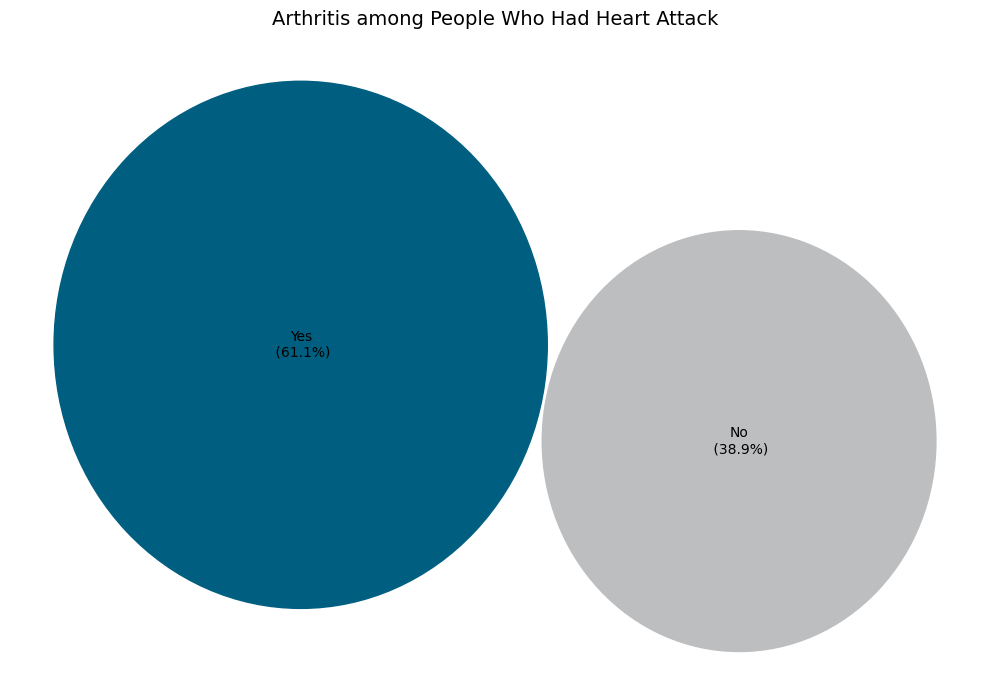

In [21]:
# ––––––––––––––––––––
#   Prepare The Data
# ––––––––––––––––––––

# Filter people who had Heart Attack
heart_attack_yes = heart_sample[heart_sample['HadHeartAttack'] == 'Yes'].copy()

# Count of Arthritis among those with Heart Attack
ct = heart_attack_yes['HadArthritis'].value_counts().reset_index()
ct.columns = ['HadArthritis', 'Count']

# Calculate percentage
ct['Percentage'] = (ct['Count'] / ct['Count'].sum() * 100).round(1)

# Prepare labels with count and percentage
ct['Label'] = ct.apply(lambda row: f"{row['HadArthritis']}\n ({row['Percentage']}%)", axis=1)

# Bubble Chart Setup
areas = ct['Count'].values
labels = ct['Label'].values
colors = ['#005f80' if x == 'Yes' else '#bdbec0' for x in ct['HadArthritis']]



# ––––––––––––––––––––
#       Plotting
# ––––––––––––––––––––

# Create BubbleChart
bubble_chart = BubbleChart(area=areas, bubble_spacing=0.1)

# Collapse (pack) the bubbles
bubble_chart.collapse(n_iterations=100)

fig, ax = plt.subplots(figsize=(10, 7))
bubble_chart.plot(ax, labels, colors)

ax.set_title('Arthritis among People Who Had Heart Attack', fontsize=14, pad=20)
ax.axis('off')   # Hide axes for clean bubble look
ax.relim()
ax.autoscale_view()

plt.tight_layout()
plt.show()

**Code Explanation**

The code creates a population with those who have heart disease, counts the different classes of HadArthritis and convert the raw counts into precentage for faster understaning on the chart.

**Interpretation**

The bubble chart suggest people who had heart attack are more likely to experience arthritis. In this dataset, the number of people with who had heart attack and have arthritis are almost double the number of people who doesn't have arthritis despite the heart attack. This raise severe concerns regarding the potential association between the two disease and calls for serious investigation from HHS.

# Q5. Which states in the US has the highest population of heart attack and diabetes?

**Business Importance**

The importance of this question lies on the fact that knowing which states have the highest population of diabetes and heart attack helps HHS to allocate the funds and resources on the states where they can benefit from it the most. It is also important for investigation purposes to find out what causes the high numbers in those states.

In [22]:
# ––––––––––––––––––––
#   Prepare The Data
# ––––––––––––––––––––

# Calculate percentages per state for both conditions
agg_df = heart_sample.groupby('State').agg(
    pct_heart_attack = ('HadHeartAttack', lambda x: (x == 'Yes').mean() * 100),
    pct_diabetes     = ('HadDiabetes',     lambda x: (x == 'Yes').mean() * 100)
).reset_index()

# Map 2-letter codes for all state names
state_to_code = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'District of Columbia': 'DC',
    'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL',
    'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA',
    'Maine': 'ME', 'Maryland': 'MD', 'Massachusetts': 'MA', 'Michigan': 'MI',
    'Minnesota': 'MN', 'Mississippi': 'MS', 'Missouri': 'MO', 'Montana': 'MT',
    'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ',
    'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND',
    'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA',
    'Rhode Island': 'RI', 'South Carolina': 'SC', 'South Dakota': 'SD',
    'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA',
    'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY',
    'Guam': 'GU', 'Puerto Rico': 'PR', 'Virgin Islands': 'VI',
}

agg_df['State_code'] = agg_df['State'].map(state_to_code)

# Check for unmatched states
unmatched = agg_df[agg_df['State_code'].isna()]
if not unmatched.empty:
    print("Unmatched states:", unmatched['State'].unique())

# Create the scatter geo map
fig = px.scatter_geo(
    agg_df,
    locations='State_code',
    locationmode='USA-states',
    size='pct_heart_attack',
    color='pct_diabetes',
    size_max=55,
    scope='usa',
    projection='albers usa',
    title='precentage of people with heart attack (size) and people with diabetes (color) in US States',
    hover_name='State',
    hover_data={
        'pct_heart_attack': ':.1f',
        'pct_diabetes':     ':.1f',
        'State_code': False
    },
    color_continuous_scale='ice')

# Improve map appearance
fig.update_geos(
    showcountries=False,
    showcoastlines=True,
    showland=True,
    landcolor='lightgray',
    showsubunits=True,
    subunitcolor='white'
)

fig.update_layout(
    height=650,
    margin={"r":0, "t":70, "l":0, "b":0},
    coloraxis_colorbar=dict(
        title="% Diabetes",
        ticksuffix="%",
        len=0.7,
        y=0.5,
        yanchor="middle"
    )
)

fig.show()

**Code Explanation**

The code seperately calculates the precentage of people with diabete and heart attack and store the rows in a dataframe. It then adds a new column that uses the postal abbreviations of each state instead of the full name. It is done so that this column meets the standard of px.scatter_geo(), making plotting possible. Finally it checks if there are any mismatch in the name of the states, and then plot the US map.

**Interpretation**

The map displays that


# Discussion and Conclusion

**Strengths**

The pipeline has been preproceed to be clean and is reproducible. Patterns are effectively illustrated using various charts and graphs that is suitable for visualizing each specific type of information (e.g, bar chart for comparing numerical categories and map for distribution of disease accross US states). Clutters are removed, colors are thoughtfully chosen to draw attention where it's needed, and the palette is color-blind friendly. The graphs adopted several design principles such as Gestalt to make complex patterns immediately understandable. The analysis focuses on critical information regarding vulnariable groups of people and the well-being of citizens which calls for actionable plans, and not merely pure statistics.


**Limitations**

Due to computational expenses, the dataset had to be reduced to only 3000 rows, which makes identifying subtle patterns challenging. The dataset lacks information such as if participants have family history of diabetes or heart disease, or their occupation (which can be helpul to undestand if there are associations with certain professions and high-risk diseases.). The dataset can be biased since it is based on people's responses to a survey.


**Insights and Implications**

*   Certain diseases heavily influence or reinforce other conditions in the body.
*   A significant group of people did not have recieved neccerassy vaccin  that is life-saving for their current condition.
*   Physical activity have undeniable improvement and preventive effect on the well-being of people even on those with serious diseases.
*   Some diseases are more prevaled in certain states compare to others.


**Data-Driven Recommendations**

*   Implementing a Bidirectional Screening protocol for the respective organizations such as hospitals and clinics to follow. According to this protocol, people with kidney disease should be monitored for diahetes, and likewise, people with diabetes should be screened for kidney disease more consistently and frequently to ensure preventive actions can be make before the diseases develop further.
*   A through investigation is recommended to find out what factors caused one third of people with diabetes to not recieve Pneumococcal vaccin.
*   An awareness-bringing campaing can be planned to informe, educate and encourage people, specially those with diabetes, to participate in more physical activities than before.
*   Support for additional epidemiologic analysis is recommended to confirm the strength of the association between heart attack and arthritis after adjusting for age, obesity, smoking, and physical inactivity,
*   Resources, funds and professional help must be allocated to different states based on their current need and prevalance of diseases. Moreover, a comperhensive research can be conducted to find out why certain states suffer from severe diseases more than others.




# References

[1] https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease/data$0

[2] https://matplotlib.org/stable/gallery/misc/packed_bubbles.html$0

[3]https://github.com/kamilpytlak/data-science-projects/blob/main/heart-disease-prediction/2022/documentation/vars_list_with_descriptions.txt$0
